In [ ]:
import torch
import numpy as np

In [ ]:
data = [[1, 2], [3, 4],[34,56],[-1,0]]
x_data = torch.tensor(data)
print( x_data.shape)

# From a NumPy array

np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print( x_data.shape, np_array.shape)
print(type(x_data.shape), type(np_array.shape))

torch.Size([4, 2])
torch.Size([4, 2]) (4, 2)
<class 'torch.Size'> <class 'tuple'>


In [ ]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1],
        [1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.3279, 0.8141],
        [0.3041, 0.0828],
        [0.9924, 0.5158],
        [0.0685, 0.2502]], dtype=torch.float32) 



In [ ]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float64
Device tensor is stored on: cpu


In [ ]:
i = 42

# Generator

#### Why not just use torch.rand() directly? Why use torch.Generator for random sampling?

Heart of reproducibility and control in PyTorch
#### Why not just use `torch.rand()` directly?

If you call `torch.rand()` or `torch.randn()` without a generator, PyTorch uses the **global RNG (Random Number Generator)**.  That means all random ops share the same stream of randomness. This is fine for quick experiments, but in serious ML workflows you often need **independent, reproducible random streams**.

#### Why use `torch.Generator`?

`torch.Generator` gives you **fine-grained control over randomness**:

1. **Independent random streams**
   * You can create multiple generators, each with its own seed.
   * Example: one generator for dataset shuffling, another for weight initialization.
   * This prevents interference between different parts of your pipeline.

2. **Reproducibility**
   * Setting a seed on a generator ensures you get the same random numbers every run.
   * Critical for debugging and scientific experiments.

3. **Device-specific randomness**
   * You can create generators tied to CPU or CUDA.
   * Example: `torch.Generator(device="cuda")` ensures reproducible randomness on GPU.

4. **Parallel training**
   * In distributed training, each worker can have its own generator, avoiding collisions in random sampling.

## Random Sampling (Initialization & Data Augmentation)
Functions: torch.rand, torch.randn, torch.randint, torch.randperm. In-place versions: tensor.normal_(), tensor.uniform_(). Functions (`bernoulli`, `multinomial`, `normal`, `poisson`, `rand`, `rand_like`, `randint`) are **random sampling APIs in PyTorch**, not the `torch.Generator` itself.


In [ ]:
import torch

# Create a generator object
gen = torch.Generator()
i = i+42
print(i)
# Set a manual seed for reproducibility
torch.manual_seed(i)        # global seed
gen.manual_seed(1234)        # generator-specific seed

# Use the generator to produce random numbers
x = torch.rand(3, 3, generator=gen)   # 3x3 matrix of random values
y = torch.rand(3, 3, generator=gen)   # another 3x3 matrix

print("First random matrix:\n", x)
print("Second random matrix:\n", y)


84
First random matrix:
 tensor([[0.2318, 0.0788, 0.4664],
        [0.4144, 0.3904, 0.2697],
        [0.1988, 0.2342, 0.2694]])
Second random matrix:
 tensor([[0.9100, 0.8098, 0.0380],
        [0.7321, 0.6137, 0.2736],
        [0.3298, 0.3143, 0.1978]])


#### In each run i value change & seed change. then why random output not change?

The random output does not change because your random matrices x and y are explicitly tied to the local generator gen, which completely ignores your changing variable i. Your random matrices ignore the global seed When you create your random matrices, you pass a specific keyword argument:
```python
x = torch.rand(3, 3, generator=gen)
```
 Drop the local generator entirely i.e. Remove the generator argument so PyTorch falls back to using the global seed controlled by i
```python
 x = torch.rand(3, 3)  # Uses torch.manual_seed(i) automatically
```
OR
```python
torch.manual_seed(i)
gen.manual_seed(i)
torch.rand(3, 3, generator=gen)
```

In [ ]:
import torch

# Create a generator object
gen = torch.Generator()
i = i+42
print(i)
# Set a manual seed for reproducibility
torch.manual_seed(i)        # global seed
gen.manual_seed(i)        # generator-specific seed

# Use the generator to produce random numbers
x = torch.rand(3, 3, generator=gen)   # 3x3 matrix of random values
y = torch.rand(3, 3, generator=gen)   # another 3x3 matrix

print("First random matrix:\n", x)
print("Second random matrix:\n", y)

126
First random matrix:
 tensor([[0.3925, 0.4391, 0.0081],
        [0.5001, 0.3462, 0.4776],
        [0.9325, 0.3932, 0.7943]])
Second random matrix:
 tensor([[0.9640, 0.7019, 0.1386],
        [0.7695, 0.1108, 0.3441],
        [0.9417, 0.6623, 0.0019]])


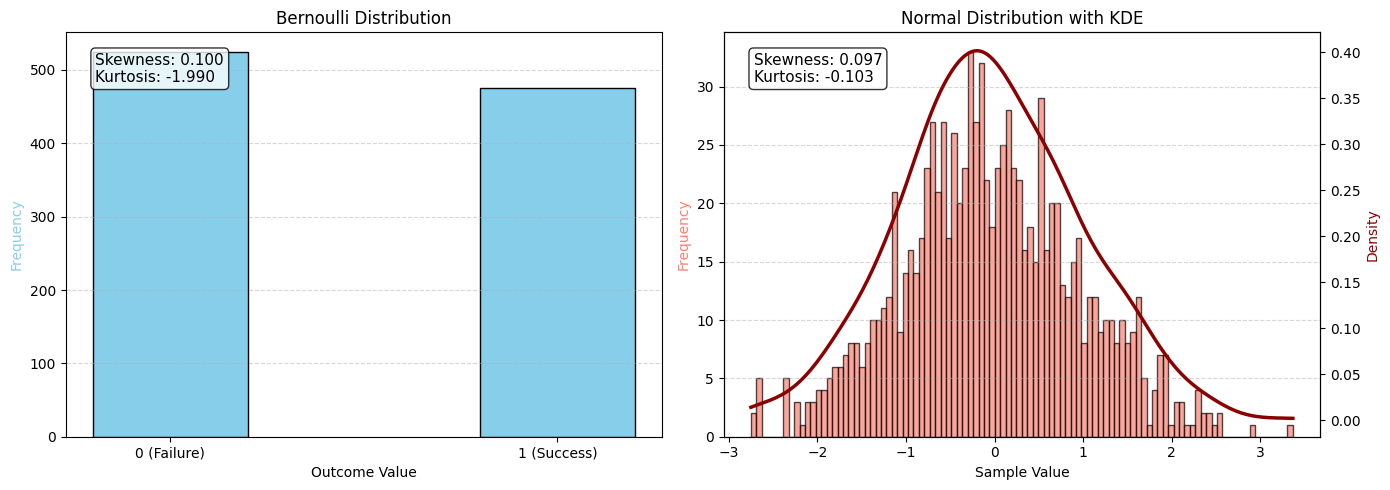

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Set seed for reproducibility
torch.manual_seed(42)

# ==========================================
# DATA GENERATION
# ==========================================
# Subplot 1: Bernoulli Distribution
bernoulli_probs = torch.rand(1000)
bernoulli_samples = torch.bernoulli(bernoulli_probs).numpy()

# Subplot 2: Normal Distribution
normal_samples = torch.randn(1000).numpy()

# ==========================================
# STATISTICAL ANNOTATIONS CALCULATIONS
# ==========================================
b_skew = stats.skew(bernoulli_samples)
b_kurt = stats.kurtosis(bernoulli_samples, fisher=True)

n_skew = stats.skew(normal_samples)
n_kurt = stats.kurtosis(normal_samples, fisher=True)

# ==========================================
# PLOTTING (1 Row, 2 Columns Layout)
# ==========================================
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# --- Left Column: Bernoulli ---
axes[0].hist(bernoulli_samples, bins=[-0.5, 0.5, 1.5], rwidth=0.4, color='skyblue', edgecolor='black')
axes[0].set_title('Bernoulli Distribution')
axes[0].set_xlabel('Outcome Value')
axes[0].set_ylabel('Frequency', color='skyblue')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (Failure)', '1 (Success)'])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

bernoulli_text = f"Skewness: {b_skew:.3f}\nKurtosis: {b_kurt:.3f}"
axes[0].text(0.05, 0.95, bernoulli_text, transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Right Column: Normal with Dual-Axis KDE ---
# Plot the frequency histogram on the primary y-axis
axes[1].hist(normal_samples, bins=100, color='salmon', edgecolor='black', alpha=0.7, label='Frequency')
axes[1].set_title('Normal Distribution with KDE')
axes[1].set_xlabel('Sample Value')
axes[1].set_ylabel('Frequency', color='salmon')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Create a twin y-axis to overlay the probability density KDE line
ax2 = axes[1].twinx()
kde = stats.gaussian_kde(normal_samples)
x_axis = np.linspace(normal_samples.min(), normal_samples.max(), 200)
ax2.plot(x_axis, kde(x_axis), color='darkred', linewidth=2.5, label='KDE (Density)')
ax2.set_ylabel('Density', color='darkred')

# Add metrics text box to the normal distribution plot
normal_text = f"Skewness: {n_skew:.3f}\nKurtosis: {n_kurt:.3f}"
axes[1].text(0.05, 0.95, normal_text, transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


## serialization in PyTorch

the functions `torch.save()` and `torch.load()`

`torch.save(obj, file)` Saves a PyTorch object (like a tensor, model, optimizer state, or dictionary) to disk.

`torch.load(file)` Loads an object previously saved with torch.save().

In [ ]:
# Example tensor
x = torch.randn(3, 3)
# Save tensor to file
torch.save(x, "tensor.pt")
# Load tensor back
y = torch.load("tensor.pt")
print(y)   # same values as x

tensor([[-1.0297, -0.4661,  0.5478],
        [-0.0436,  0.0909,  0.8509],
        [ 0.4911, -1.9602,  1.3435]])


In In neural networks, torch.save() model weights and optimizer state. 

### Benefits of Saving Model Weights

* **Checkpointing training:** You can pause training and resume later without starting over.
* **Deployment:** Save the trained model and load it in production for inference.
* **Reproducibility:** Ensures you can reproduce results exactly with the same parameters.
* **Transfer learning:** Load pretrained weights into a new model and fine-tune.

### Benefits of Saving Optimizer State

* **Resume training seamlessly:** Optimizers like Adam, RMSProp, or SGD with momentum keep internal buffers (momentum terms, adaptive learning rates). If you only save weights, resuming training resets these buffers → training dynamics change.
* **Consistent convergence:** Preserving optimizer state ensures the learning rate schedule and momentum continue smoothly.
* **Avoid wasted epochs:** Without optimizer state, the model may need extra epochs to "re-stabilize" after resuming.


## CPU parallelism 

In PyTorch, CPU parallelism controls let you manage how many CPU threads are used when performing tensor operations. Since many tensor computations (like matrix multiplication, convolution, etc.) can be split across multiple cores, PyTorch provides functions to query and adjust this behavior.

#### Two Types of Parallelism

1. **Intra-operation parallelism**
   * Splits a single operation (e.g., a big matrix multiply) across multiple threads.
   * Controlled by:
     * `torch.get_num_threads()` → check current thread count
     * `torch.set_num_threads(n)` → set number of threads

2. **Inter-operation parallelism**
   * Runs multiple independent operations in parallel (e.g., in JIT interpreter).
   * Controlled by:
     * `torch.get_num_interop_threads()` → check inter-op threads
     * `torch.set_num_interop_threads(n)` → set inter-op threads

#### Other Controls

* `init_num_threads()` → initializes threading system (usually internal).
* `fork()` → returns number of threads used for CPU ops.
* `wait()` → synchronizes threads, ensuring all parallel tasks finish before continuing.

#### Why It Matters in ML

* **Performance optimization:** On multi-core CPUs, parallelism speeds up tensor math.
* **Resource management:** You can limit threads so PyTorch doesn't hog all CPU cores (important on shared servers).
* **Reproducibility:** Fixing thread counts can make experiments more consistent across runs.
* **Debugging:** Sometimes reducing threads helps isolate performance bottlenecks.

#### I can understand fork() in Linux create new process with  create a new process by duplicating the existing process. How torch fork different from ?

In `Linux`, `fork()` is a **system call** that creates a **new process** by duplicating the current one. That means you suddenly have two independent processes (parent and child), each with its own memory space, file descriptors, etc.

In PyTorch, however, the function named `fork()` in the parallelism API is not the same thing. It **does not create a new process**. Instead:

* **PyTorch `fork()`** → simply returns the number of threads currently being used for CPU parallelization.
* It's a **query function**, not a process-creation function.
* It's part of PyTorch's **threading control utilities** (like `get_num_threads`, `set_num_threads`) that manage how tensor operations are parallelized across CPU cores.


In [ ]:
import torch
import time

def test_threads(n_threads):
    torch.set_num_threads(n_threads)
    print(f"\nUsing {torch.get_num_threads()} intra-op threads")

    a = torch.randn(2000, 2000)
    b = torch.randn(2000, 2000)

    start = time.time()
    c = torch.mm(a, b)   # matrix multiply
    end = time.time()

    print("Time taken:", round(end - start, 4), "seconds")

# --- Intra-operation parallelism ---
print("Default intra-op threads:", torch.get_num_threads())

torch.set_num_threads(2)
print("After setting intra-op threads to 2:", torch.get_num_threads())

torch.set_num_threads(8)
print("After setting intra-op threads to 8:", torch.get_num_threads())

# --- Inter-operation parallelism ---
print("Default inter-op threads:", torch.get_num_interop_threads())

#torch.set_num_interop_threads(4)
print("After setting inter-op threads to 4:", torch.get_num_interop_threads())

# --- init_num_threads() ---
torch.init_num_threads()
print("Threads initialized (still reports):", torch.get_num_threads())

# --- Verify intra-op parallelism ---
print("Default intra-op threads:", torch.get_num_threads())

# Compare performance with different thread counts
test_threads(1)
test_threads(4)
test_threads(8)

# --- Inter-op threads (read-only after start) ---
print("\nInter-op threads (read-only):", torch.get_num_interop_threads())

Default intra-op threads: 8
After setting intra-op threads to 2: 2
After setting intra-op threads to 8: 8
Default inter-op threads: 10
After setting inter-op threads to 4: 10
Threads initialized (still reports): 8
Default intra-op threads: 8

Using 1 intra-op threads
Time taken: 0.3854 seconds

Using 4 intra-op threads
Time taken: 0.1517 seconds

Using 8 intra-op threads
Time taken: 0.6187 seconds

Inter-op threads (read-only): 10


## Try Parallelism with example 
TODO

## Locally disabling gradient computation

##### what is meaning Locally disabling gradient computation? Why I need to disable it? What is locally? In which situations I use this?

#### What "Locally disabling gradient computation" means?

* **Gradient computation** = PyTorch tracks operations on tensors with `requires_grad=True` so it can later compute derivatives (backpropagation).
* **Locally disabling** = turning off gradient tracking *only* inside a specific block of code (using context managers like `torch.no_grad()` or `torch.set_grad_enabled(False)`), without affecting the rest of your program.
* It's "local" because the setting applies only inside the `with ...:` block or until you re-enable it.

#### Why disable gradients?

1. **Inference / Evaluation**
   * When you're just running the model to make predictions, you don't need gradients.
   * Disabling them saves memory and speeds up computation.

2. **Freezing parts of a model**
   * In transfer learning, you may want to train only the last layer while keeping earlier layers fixed.
   * Disabling gradients for those frozen layers prevents unnecessary computation.

3. **Efficiency in utilities**
   * Logging, visualization, or feature extraction often don't require gradients.
   * Disabling avoids overhead.
4. What “locally” means It’s not global — you don’t permanently turn off autograd.

```python
x = torch.ones(1, requires_grad=True)

with torch.no_grad():       # local block
    y = x * 2
print(y.requires_grad)      # False

z = x * 3
print(z.requires_grad)      # True (outside block, gradients back on)
```

#### Situations where you use this

* **Model evaluation / testing** → `torch.no_grad()` around `model(x)` calls.
* **Feature extraction** → when you only want outputs, not gradients.
* **Transfer learning** → freeze pretrained layers.
* **Memory-sensitive tasks** → disabling gradients reduces GPU RAM usage.


## Inference mode

#### torch.is_inference_mode_enabled — what it means

`torch.is_inference_mode_enabled()` returns **True** when PyTorch's *inference mode* is active. 

Inference mode is a global, higher-performance context intended for model evaluation and deployment where gradients and certain runtime checks are disabled to make forward passes faster and use less memory.

#### Why inference mode exists

* **Performance:** It reduces overhead (fewer checks, no autograd bookkeeping), so forward passes run faster.
* **Memory:** It avoids storing intermediate tensors needed for gradient computation, lowering memory usage.
* **Safety for inference:** It prevents accidental gradient accumulation or autograd state changes during evaluation.

#### Template:

```python
import torch

# Context manager style
with torch.inference_mode():
    outputs = model(inputs)
    # torch.is_inference_mode_enabled() -> True inside this block

# Functional check
if torch.is_inference_mode_enabled():
    # code that assumes inference-only behavior
    pass
```

#### When to use it

**Model evaluation** on validation/test sets where you never need gradients. **Serving / production inference** to maximize throughput and reduce memory. **Library code** that should behave differently in training vs inference (e.g., skip expensive checks or extra logging when in inference).

#### Caveats and best practices

* **Don't enable inference mode** if you need to compute gradients or call `.backward()`.
* **Some debugging or safety checks** are skipped in inference mode; use it only when you're confident about correctness.
* **If you only need to avoid gradient tracking** but still want some runtime checks, `torch.no_grad()` may be more appropriate.


#### Math operations in torch is different from NumPy math operations is only for torch support c++ & NumPy is the python library and it affect speed and optimizations ?

Yes — PyTorch math operations differ from NumPy’s because PyTorch is built on a C++ backend with its own tensor semantics, autograd, and device support (CPU/GPU), while NumPy is a Python library with C implementations focused on CPU arrays. Those architectural differences change behavior, available features, and performance/optimizations.


| Aspect | PyTorch (torch) | NumPy |
| :--- | :--- | :--- |
| **Core implementation** | C++ backend (ATen/TorchScript/CUDA kernels) | C (and C/Fortran libraries like BLAS) |
| **Primary object** | `torch.Tensor` with device, dtype, and autograd metadata | `numpy.ndarray` (CPU-only) |
| **Autograd / gradients** | Built-in automatic differentiation (tracks ops) | No autograd by default |
| **Device support** | CPU and GPU (CUDA, ROCm) with explicit device placement | CPU only (unless using extensions like CuPy) |
| **In-place semantics & versioning** | Tracks version counters; some ops have in-place variants that affect autograd | Simpler semantics; no autograd bookkeeping |
| **Broadcasting & API** | Similar broadcasting rules, but some ops and dtypes differ | Standard NumPy broadcasting and dtype promotion |
| **Performance tuning** | Kernel implementations per device; fused kernels, JIT, inference mode, mixed precision | Relies on optimized BLAS/LAPACK; single-device CPU optimizations |

#### Why these differences matter for speed and optimization

1. **Backend kernels**
   * PyTorch ships device-specific kernels (C++/CUDA) optimized for parallel hardware. 
   * NumPy calls optimized CPU libraries (BLAS/LAPACK). 
   * On GPU workloads PyTorch is far faster because NumPy has no native GPU support.

2. **Autograd overhead**
   * When autograd is enabled, PyTorch records operations and allocates metadata. That adds overhead compared with NumPy. 
   * Using `torch.no_grad()` or `torch.inference_mode()` removes that overhead and speeds up forward passes.

3. **Memory and intermediate storage**
   * PyTorch can avoid storing intermediates when inference mode is on.
   * NumPy never stores gradient info, so for pure forward CPU math NumPy can be leaner, but PyTorch's fused kernels and GPU parallelism usually win for large workloads.

4. **Operator implementations and fusing**
   * PyTorch can fuse multiple ops into a single kernel (or use JIT/inductor) to reduce memory traffic and kernel launch overhead. 
   * NumPy's ops are typically separate calls into BLAS or elementwise loops.

5. **Device transfers and async execution**
   * PyTorch supports asynchronous GPU execution and explicit device transfers; moving data between CPU and GPU is a major performance factor. 
   * NumPy runs synchronously on CPU.

6. **Dtype and precision optimizations**
   * PyTorch supports mixed precision (e.g., `float16`, `bfloat16`) and automatic mixed precision tooling to speed up GPU inference/training. 
   * NumPy primarily uses `float32` / `float64` on CPU.

#### When use Numpy & PyTorch im Math Operations

* **If you need GPU or large-scale parallelism:** use **PyTorch** (or CuPy for NumPy-like GPU arrays).
* **If you only need CPU numeric work and want NumPy API:** use **NumPy**; it's simple and efficient for many tasks.
* **For inference in PyTorch:** wrap code in `torch.inference_mode()` or `torch.no_grad()` to remove autograd overhead.
* **For tight loops or microbenchmarks:** prefer vectorized ops and avoid Python loops; compare implementations with realistic data and measure.
* **If you want NumPy API but GPU speed:** consider **CuPy** or convert arrays to PyTorch tensors for GPU kernels.
#### Example: why timings differ (conceptual)

* NumPy `a + b` on CPU calls a highly optimized C loop or BLAS routine and returns an `ndarray`.
* PyTorch `a + b` may record the op for autograd, update tensor version counters, and (if on GPU) launch a CUDA kernel asynchronously. If you disable grad tracking and use appropriate dtype/device, PyTorch's kernel can be much faster for large arrays on GPU.



For Math operations support by PyTorch  [see this link](https://docs.pytorch.org/docs/2.14/torch.html#math-operations)

# Tensor [LINK](https://docs.pytorch.org/docs/2.14/torch.html#tensors)

## Storage in PyTorch?

`torch.is_storage()` is a utility function in PyTorch that checks whether a given object is a **storage object** (the low-level memory buffer behind tensors). It returns `True` for storage objects and `False` for tensors or other Python objects.

#### What is a Storage in PyTorch?

* **Storage** is the underlying memory container that holds raw data for tensors.
* A **tensor** is essentially a view on top of a storage with shape, stride, and metadata.
* `torch.is_storage(obj)` helps distinguish between a tensor and its backing storage.


In [ ]:
import torch

tensor = torch.tensor([1, 2, 3])
print(torch.is_storage(tensor))   # False

typed_storage = torch.TypedStorage(5, dtype=torch.float32)
print(torch.is_storage(typed_storage))  # True

False
True


#### I didn't understand why this is false "torch.tensor([1,2,3])". Storage menace what? additional memory on RAM like malloc. Or any thing else? What happen if torch.FloatStorage(6) give result false?

#### Why `torch.tensor([1,2,3])` returns False?

A **tensor is not a storage**. A tensor is a **view**: it has shape, stride, dtype, device, etc.Underneath, every tensor is backed by a **storage object** (the raw memory buffer). So when you call `torch.is_storage(tensor)`, it's false because you're passing the view, not the raw memory.

Think of **storage** like `malloc` in C. It's a **contiguous block of memory** allocated in RAM (or GPU memory if the tensor is on CUDA). It doesn't know about dimensions, shapes, or strides — it's just raw memory. Tensors are "wrappers" that interpret this memory as multi-dimensional arrays. So yes, your intuition is right: storage is essentially the **allocated memory buffer**.

```python
a = torch.FloatStorage(6)   # creates a storage of size 6
print(a)                    # shows raw memory values
```


#### Data Type Functions
- torch.set_default_tensor_type(torch.FloatTensor) → this is the default tensor type for 32‑bit floating point (float32).
- torch.set_default_tensor_type(torch.DoubleTensor) → this is the tensor type for 64‑bit floating point (float64).

In [ ]:
import torch

In [ ]:
torch.set_default_device("cpu")
# Default is usually torch.float32
x = torch.tensor([1.0, 2.0])
print(x.dtype)   # torch.float32

# Change default to float64
torch.set_default_dtype(torch.float64)
y = torch.tensor([1.0, 2.0])
print(y.dtype)   # torch.float64


torch.float64
torch.float64


#### Device Functions
Sets the default device for tensor creation.

- `torch.set_default_device("cuda")` That means every new tensor tries to be created on the GPU.
- `torch.set_default_device("cpu")`    force tensors to be created on CPU.

So if you run `torch.set_default_device("cuda")` on non supported GPU, then when you created tensor after this set, then you will gen an error. So for non GPU device you must set `torch.set_default_device("cpu")`.

```python 
# Set default device to GPU if available
torch.set_default_device("cuda")
a = torch.tensor([1, 2, 3])
print(a.device)  # cuda:0
```
Above code raise errror on non gpu suported device. For non-gpu you can set `torch.set_default_device("cpu")`

#### What are denormal (subnormal) numbers?

* In floating-point math, **denormals** are extremely tiny numbers (close to zero, smaller than the minimum representable normalized float). **Example:** values around `1e-308` in `float64` or `1e-45` in `float32`.CPUs handle denormals **much more slowly** than normal floats, which can cause performance drops in numerical code. `torch.set_flush_denormal(True)` If set to **True**, PyTorch will **flush denormal numbers to zero**. This **avoids the performance penalty** but sacrifices precision for those ultra-tiny values. If set to **False**, PyTorch keeps denormals as they are (slower, but more precise).

#### When is it required?

* **High-performance training/inference:** If your model generates denormals (e.g., during gradient updates with very small learning rates), flushing them can speed things up.
* **Scientific computing:** If you care about every tiny bit of precision, you should keep denormals (set to `False`).
* **Deep learning practice:** Most practitioners enable flushing because those tiny values don't affect learning but can slow down training.


In [ ]:
import torch

# Create a very tiny number (denormal in float32)
x = torch.tensor([1e-45], dtype=torch.float32)
print("Before flush:", x)

# Enable flush denormal
torch.set_flush_denormal(True)
y = torch.tensor([1e-45], dtype=torch.float32)
print("After flush:", y)


Before flush: tensor([0.], dtype=torch.float32)
After flush: tensor([0.], dtype=torch.float32)


## Tensor creation operations [LINK](https://docs.pytorch.org/docs/2.14/torch.html#creation-ops)

Random sampling creation ops are listed under [Random sampling](https://pytorch.org) and include:

* `torch.rand()`
* `torch.rand_like()`
* `torch.randn()`
* `torch.randn_like()`
* `torch.randint()`
* `torch.randint_like()`
* `torch.randperm()`

You may also use `torch.empty()` with the [In-place random sampling](https://pytorch.org) methods to create `torch.Tensor`s with values sampled from a broader range of distributions.

### Sparse tensors
**Sparse tensors** are special data structures that store only non-zero values and their positions, saving memory and speeding up operations when most entries are zero. PyTorch supports several layouts: **COO, CSR, CSC, BSR, and BSC**, each optimized for different access patterns.

#### Why Sparse Tensors?
* **Dense tensors** store every element, including zeros $\rightarrow$ wasteful for large matrices with mostly zeros.
* **Sparse tensors** store only non-zero values + indices $\rightarrow$ efficient for graph adjacency matrices, NLP vocab embeddings, pruned neural networks, etc.


| Layout | Name | How it works | Best Use Case / Advantage |
| :--- | :--- | :--- | :--- |
| **COO** | Coordinate format | Stores list of `(row, col, value)` for each non-zero | General sparse data, easy to construct and convert |
| **CSR** | Compressed Sparse Row | Stores non-zeros row by row, with row pointers | Fast row slicing, matrix-vector multiplication |
| **CSC** | Compressed Sparse Column | Stores non-zeros column by column, with column pointers | Fast column slicing, transpose operations |
| **BSR** | Block Sparse Row | Like CSR but groups non-zeros into fixed-size blocks | Efficient for structured sparsity (e.g., block-pruned weights) |
| **BSC** | Block Sparse Column | Like CSC but block-based | Efficient for column-structured sparsity |


In [ ]:
import torch
a = torch.tensor([[0, 2.], [3, 0]])
s = a.to_sparse()
print('=============== sparse ================')
print(s)

csr = torch.sparse_csr_tensor(
    crow_indices=torch.tensor([0,1,2]),
    col_indices=torch.tensor([1,0]),
    values=torch.tensor([2.,3.]),
    size=(2,2)
)
print('=============== csr ================')
print(csr)

csc = torch.sparse_csc_tensor(
    ccol_indices=torch.tensor([0,1,2]),
    row_indices=torch.tensor([1,0]),
    values=torch.tensor([3.,2.]),
    size=(2,2)
)
print('=============== csc ================')
print(csc)
bsr = torch.sparse_bsr_tensor(
    crow_indices=torch.tensor([0,1,2]),
    col_indices=torch.tensor([0,1]),
    values=torch.randn(2,2,2),  # block size 2x2
    size=(4,4)
)
print('=============== bsr ================')
print(bsr)
bsc = torch.sparse_bsc_tensor(
    ccol_indices=torch.tensor([0,1,2]),
    row_indices=torch.tensor([0,1]),
    values=torch.randn(2,2,2),
    size=(4,4)
)
print('=============== bsc ================')
print(bsc)

=============== sparse ================
tensor(indices=tensor([[0, 1],
                       [1, 0]]),
       values=tensor([2., 3.]),
       size=(2, 2), nnz=2, layout=torch.sparse_coo)
=============== csr ================
tensor(crow_indices=tensor([0, 1, 2]),
       col_indices=tensor([1, 0]),
       values=tensor([2., 3.]), size=(2, 2), nnz=2, layout=torch.sparse_csr)
=============== csc ================
tensor(ccol_indices=tensor([0, 1, 2]),
       row_indices=tensor([1, 0]),
       values=tensor([3., 2.]), size=(2, 2), nnz=2, layout=torch.sparse_csc)
=============== bsr ================
tensor(crow_indices=tensor([0, 1, 2]),
       col_indices=tensor([0, 1]),
       values=tensor([[[-1.1486,  0.5586],
                       [-1.6333, -0.3261]],

                      [[-1.7600,  0.5536],
                       [-0.2583,  1.3343]]]), size=(4, 4), nnz=2,
       layout=torch.sparse_bsr)
=============== bsc ================
tensor(ccol_indices=tensor([0, 1, 2]),
       row_indices=t

## Memory operations in pytorch tensor

#### 1. Assigning / Creating Tensors

These control how memory is allocated when you first make a tensor:

* `torch.tensor([...])` \(\rightarrow\) always copies data into a new tensor.
* `torch.as_tensor(data)` \(\rightarrow\) creates a tensor that *shares memory* with the source (NumPy array, list, etc.) if possible.
* `torch.from_numpy(ndarray)` \(\rightarrow\) shares memory with NumPy arrays (changes in one reflect in the other).
* `torch.empty(size)` \(\rightarrow\) allocates uninitialized memory (fast, but contents are garbage until filled).
* `torch.zeros`, `torch.ones`, `torch.full` \(\rightarrow\) allocate and initialize memory with fixed values.

#### 2. Copying / Moving Data

These affect whether data is duplicated or just referenced:

* `tensor.clone()` \(\rightarrow\) makes a full copy of the tensor (new memory).
* `tensor.detach()` \(\rightarrow\) creates a view without gradient tracking, but shares memory.
* `tensor.to(device)` \(\rightarrow\) copies tensor to another device (CPU \(\leftrightarrow\) GPU).
* `tensor.copy_()` \(\rightarrow\) in-place copy from another tensor.
* `tensor.view()` / `tensor.reshape()` \(\rightarrow\) create new views (no copy, just different shape metadata).
* `tensor.contiguous()` \(\rightarrow\) ensures tensor memory is contiguous; may copy if needed.

#### 3. Optimizing Memory Usage

These APIs help reduce overhead or improve performance:

* `torch.set_default_dtype(dtype)` \(\rightarrow\) controls precision (float32 vs float64). Lower precision = less memory, faster compute.
* `torch.set_default_device("cuda"/"cpu")` \(\rightarrow\) controls where tensors are allocated by default.
* `torch.set_flush_denormal(True)` \(\rightarrow\) flushes tiny denormal floats to zero for speed.
* `tensor.share_memory_()` \(\rightarrow\) allows sharing tensor memory across processes.
* `tensor.pin_memory()` \(\rightarrow\) locks tensor in RAM for faster CPU\(\rightarrow\)GPU transfers.
* `tensor.untyped_storage()` \(\rightarrow\) gives access to raw memory buffer for low-level optimization.
* `torch.sparse_*_tensor()` \(\rightarrow\) sparse formats (COO, CSR, etc.) save memory when most values are zero.


## PyTorch tensor APIs GPU (CUDA) support and speed optimizations:

#### Device & CUDA APIs

* `tensor.to("cuda")` → moves a tensor to GPU.
* `tensor.cuda()` → shorthand for `.to("cuda")`.
* `torch.cuda.is_available()` → check if CUDA is supported.
* `torch.cuda.current_device()` / `torch.cuda.device_count()` → query GPU devices.
* `torch.cuda.set_device(id)` → set active GPU.
* `torch.set_default_device("cuda")` → make GPU the default for new tensors.

#### Memory Management APIs

* `tensor.pin_memory()` → lock tensor in RAM for faster CPU→GPU transfer.
* `torch.cuda.empty_cache()` → release unused GPU memory back to the system.
* `torch.cuda.memory_allocated()` / `torch.cuda.memory_reserved()` → monitor GPU memory usage.
* `tensor.share_memory_()` → share tensor memory across processes.
* `tensor.untyped_storage()` → access raw memory buffer for low-level optimization.

#### Copying & Views (Performance-critical)

* `tensor.clone()` → deep copy (new memory).
* `tensor.detach()` → view without gradients (shares memory).
* `tensor.view()` / `tensor.reshape()` → reshape without copy (metadata only).
* `tensor.contiguous()` → ensure memory layout is contiguous (may copy).
* `torch.as_tensor()` / `torch.from_numpy()` → share memory with external arrays (fast, no copy).

#### Precision & Speed Optimizations

* `torch.set_default_dtype(torch.float16 / torch.bfloat16)` → lower precision for speed/memory savings.
* `tensor.half()` / `tensor.bfloat16()` → convert tensor to half precision.
* `torch.autocast(device_type="cuda")` → automatic mixed precision (AMP) for faster training.
* `torch.backends.cudnn.benchmark = True` → optimize convolution algorithms for your hardware.
* `torch.set_flush_denormal(True)` → flush tiny floats to zero for speed.


## Indexing, Slicing, Joining, Mutating Ops [LINK](https://docs.pytorch.org/docs/2.14/torch.html#indexing-slicing-joining-mutating-ops)

TODO

## Accelerators 

In PyTorch, **Accelerators** are devices other than the CPU that can execute tensor operations faster — for example GPUs (CUDA), Apple Silicon (MPS), Intel GPUs (XPU), Habana processors (HPU), or custom/private accelerators. Think of them as the "engines" that speed up tensor math by running operations asynchronously and in parallel.

* **Device abstraction:** Each accelerator is represented as a `torch.device` (e.g., `"cuda"`, `"mps"`, `"xpu"`).
* **Async execution:** They use streams (`torch.Stream`) and events (`torch.Event`) to overlap computation and memory transfers.
* **Default device:** When you set an accelerator as the default, new tensors and operations automatically run there.
* **Performance boost:** Accelerators exploit specialized hardware (GPU cores, tensor cores, etc.) for massive speedups in ML workloads.

#### When to Use Accelerators

* **Training deep learning models:** GPUs/HPUs accelerate matrix multiplications, convolutions, and attention layers.
* **Inference at scale:** Running LLMs or CV models on accelerators reduces latency.
* **Mixed precision training:** Accelerators support FP16/BF16 for faster training with less memory.
* **Large tensor ops:** Any workload with heavy linear algebra benefits from accelerators.
* **Platform-specific optimization:**
  * CUDA \(\rightarrow\) NVIDIA GPUs
  * MPS \(\rightarrow\) Apple Silicon (Mac)
  * XPU \(\rightarrow\) Intel GPUs
  * HPU \(\rightarrow\) Habana AI processors

#### Q. How to use Accelerators pytorch tensor API for CUDA for tensor speedups?

TODO
parallelism + async execution wit pytorch CUDA.

## signal processing utilities in PyTorch

`stft`, `istft`, and the various window functions (`bartlett_window`, `blackman_window`, `hamming_window`, `hann_window`, `kaiser_window`) — are **signal processing utilities in PyTorch**. They're fully supported and are used when you want to work with time-frequency analysis or spectral filtering directly inside PyTorch tensors.

#### When to Use

* **Audio ML tasks** → speech recognition, music analysis, noise filtering.
* **Spectral analysis** → examining frequency content of signals.
* **Feature extraction** → converting raw waveforms into spectrograms for deep learning models.
* **Signal reconstruction** → after processing in frequency domain, use `istft` to get back the waveform.

TODO


## CNN API

TODO

## BLAS and LAPACK operations GPU optimization

#### What are BLAS and LAPACK?

* **BLAS (Basic Linear Algebra Subprograms)**
  A standardized set of low-level routines for vector and matrix operations (dot products, matrix multiplication, etc.).
  * Level 1: Vector operations (dot, axpy, norm).
  * Level 2: Matrix-vector operations (gemv).
  * Level 3: Matrix-matrix operations (gemm).

* **LAPACK (Linear Algebra PACKage)**
  A higher-level library built on BLAS, providing routines for solving linear systems, eigenvalue problems, and matrix factorizations (LU, QR, SVD).

PyTorch internally calls optimized BLAS/LAPACK implementations (like Intel MKL, OpenBLAS, cuBLAS on GPU) to accelerate tensor math.

#### Why PyTorch Uses Them

They are **highly optimized** (CPU vectorization, GPU parallelism). They ensure **numerical stability** for linear algebra routines. They provide **cross-platform consistency** (same math ops across CPU/GPU).

##### BLAS-style

* `torch.matmul()` → matrix multiplication (BLAS gemm).
* `torch.mm()` → matrix × matrix.
* `torch.mv()` → matrix × vector.
* `torch.dot()` → dot product.
* `torch.addmm()`, `torch.bmm()` → batched matrix multiplications.

##### LAPACK-style

* `torch.linalg.inv()` → matrix inverse (LU factorization).
* `torch.linalg.solve()` → solve linear systems.
* `torch.linalg.eig()` / `torch.linalg.eigh()` → eigenvalues/eigenvectors.
* `torch.linalg.svd()` → singular value decomposition.
* `torch.linalg.cholesky()` → Cholesky factorization.
* `torch.linalg.qr()` → QR decomposition.



## Foreach Operations

#### Explain Foreach Operations in pytorch tensor. I know abs operations in numpy. How _foreach_abs differ this?

PyTorch introduced **Foreach APIs** (prefixed with `_foreach_`) to perform the **same operation across multiple tensors in a single fused call**. Instead of looping in Python and calling `abs` on each tensor one by one, `_foreach_abs` applies the operation to a **list of tensors at once**. This reduces Python overhead and can fuse GPU kernels, giving **speed and memory efficiency**.

Imagine you have 100 tensors and want to apply `abs`. **Naive way:** loop in Python → 100 kernel launches. **Foreach way:** one fused call → fewer kernel launches, less overhead. This matters especially on **GPU workloads**, where kernel launch overhead can dominate.

* **Foreach ops** (`_foreach_*`) = vectorized operations across multiple tensors.
* `_foreach_abs` = applies absolute value to a list of tensors in one optimized call.
* **Benefit:** speed, reduced memory overhead, fewer kernel launches.
* **Use case:** training loops, optimizers, or anywhere you apply the same op to many tensors.

In [ ]:
import torch
x = torch.tensor([-1.0, 2.0, -3.0])
print('=========== without Foreach ops =================')
print(torch.abs(x))  

a = torch.tensor([-1.0, 2.0])
b = torch.tensor([-3.0, 4.0])
result = torch._foreach_abs([a, b])
print('=========== with Foreach ops ====================')
print(result)   

=========== without Foreach ops =================
tensor([1., 2., 3.])
=========== with Foreach ops ====================
(tensor([1., 2.]), tensor([3., 4.]))


## Utilities

**PyTorch "utilities" are helper functions that make tensor workflows easier: they cover type checks, default settings, random number control, serialization, parallelism, and gradient management. In ML (ANNs, CNNs), the most frequently used utilities are those for random seeding, tensor creation, serialization, and gradient control.**

PyTorch groups utilities 
* **Tensor checks & defaults**
  * `is_tensor`, `is_floating_point`, `is_complex` → check tensor properties.
  * `set_default_dtype`, `get_default_dtype` → control precision (float32 vs float64).
  * `set_default_device`, `get_default_device` → control CPU vs GPU allocation.

* **Random number generation**
  * `manual_seed`, `seed`, `get_rng_state`, `set_rng_state` → reproducibility.
  * `torch.default_generator` → global RNG.
  * Distribution APIs: `rand`, `randn`, `randint`, `bernoulli`, `poisson`, `multinomial`.

* **Serialization (saving/loading)**
  * `torch.save`, `torch.load` → checkpoint models, tensors, optimizers.
  * `from_numpy`, `from_dlpack`, `frombuffer` → convert external data into tensors.

* **Parallelism & threading**
  * `get_num_threads`, `set_num_threads` → CPU parallelism control.
  * `get_num_interop_threads`, `set_num_interop_threads` → inter-op parallelism.

* **Gradient control**
  * `torch.no_grad()`, `torch.enable_grad()`, `torch.set_grad_enabled()` → manage autograd context.
  * `inference_mode()` → disable autograd for inference speed.



## Automatic mixed precision (AMP)

In PyTorch, “autocast” refers to automatic mixed precision (AMP) — a mechanism that automatically chooses the most efficient floating-point dtype (like `float16` or `bfloat16`) for GPU operations to speed up training while maintaining accuracy. 

#### What is Autocast?

* **Automatic Mixed Precision (AMP):**
  Instead of running everything in `float32`, autocast lets certain operations run in lower precision (`float16` or `bfloat16`) for speed and memory savings, while keeping numerically sensitive ops in `float32`.
* **Benefit:** Faster training, lower memory usage, minimal accuracy loss.
* **Usage:** Typically combined with `torch.amp.autocast` context manager and `GradScaler`.

most frequently used autocast APIs in PyTorch for ML workflows (ANNs, CNNs, LLMs)

#### Core Autocast APIs

* `torch.amp.autocast(device_type="cuda", dtype=torch.float16/bfloat16)`
  Context manager that enables automatic mixed precision (AMP).
  → Most common entry point for ANN, CNN, and LLM training.

* `torch.get_autocast_gpu_dtype()`
  Returns the current GPU dtype autocast is using (`float16` or `bfloat16`).
  → Useful for debugging and ensuring consistency across devices.

* `torch.set_autocast_gpu_dtype(dtype)`
  Explicitly set autocast precision (`float16` or `bfloat16`).
  → Often used in LLM training where `bfloat16` is preferred for stability.

* `torch.amp.GradScaler()`
  Scales gradients during mixed precision training to avoid underflow.
  → Essential in CNN/LLM training loops with autocast.
